### Code Block with all Method definitions:
    - read_qasm_files_from_folder
    - random_benchmark_hellinger
    - split_lists
    - compare_counts
    - compare_experiments
    - benchmark
    - extract_labels
    - calc_supermarq_plus_features
    - create_feature_dict
    - train_model
    - train_model_long
    - generate_random_Benchmark_circuits

In [27]:
import os
import numpy as np
import re

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import make_scorer
from sklearn.model_selection import GridSearchCV
from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType

from qiskit.visualization import plot_histogram, plot_coupling_map
from qiskit import transpile,QuantumCircuit
from qiskit import qasm2

from qiskit.converters import circuit_to_dag

from qiskit_experiments.library import StandardRB
from qiskit_experiments.framework import ExperimentData

from qiskit_aer import Aer

from mqp.qiskit_provider import MQPProvider

import networkx as nx

import matplotlib as plt

import random


from dotenv import load_dotenv

from typing import List, Tuple, Dict

import pickle
from __future__ import annotations
import argparse
from pathlib import Path

import onnxruntime as ort
dotenv_path = Path(__file__).parent.parent / ".env" if "__file__" in globals() else Path().resolve().parent / ".env"
load_dotenv(dotenv_path)

True

In [3]:

def generate_random_Benchmark_circuits(qubits:List[int],lengths:List[int],num_samples:int,path:str,seed=123)->List[Tuple[str,QuantumCircuit]]:
    """!
    @brief Generates random benchmarking circuits and saves them to a file.

    This function creates a set of random benchmarking circuits based on the provided 
    parameters and saves them as a pickled list of tuples containing the circuit name 
    and the corresponding QuantumCircuit object.

    @param qubits A list of integers representing the qubits for the benchmarking circuits.
    @param lengths A list of integers representing the lengths of the benchmarking sequences.
    @param num_samples The number of random benchmarking circuits to generate for each qubit size and length.
    @param path The file path where the pickled circuits will be saved.
    @param seed The seed for random number generation (default is 123).
    
    @return A list of tuples, where each tuple contains:
        - A string representing the name of the circuit (e.g., "circuit_1").
        - A QuantumCircuit object representing the generated benchmarking circuit.
    """

    Circuits=[]
    for i in qubits:
        q_list=qubits[:i]
        rb = StandardRB(q_list, lengths, num_samples=num_samples, seed=seed)
        Circuits.append(rb.circuits())
    Circuits = [circuit for sublist in Circuits for circuit in sublist]    
    circuits_list = [(f"circuit_{i+1}", circuit) for i, circuit in enumerate(Circuits)]
    with open(path, 'wb') as f:
        pickle.dump(circuits_list, f)
    return circuits_list

In [4]:
def read_qasm_files_from_folder(folder_path)->List[QuantumCircuit]:
    """!
    @brief Reads QASM files from the specified folder and converts them into QuantumCircuit objects.
    
    This function takes a string for the path to a folder containing .qasm files,
    reads them, and converts the read strings into Qiskit QuantumCircuit objects. 
    It then returns a list of these QuantumCircuit objects.
    
    @param folder_path The path to the folder containing .qasm files.
    @return A list of QuantumCircuit objects created from the .qasm files.
    """
    # List all files in the folder
    qasm_files = [f for f in os.listdir(folder_path) if f.endswith('.qasm')]
    qasm_files=qasm_files
    # Initialize an empty list to store QuantumCircuits
    quantum_circuits = []
    
    for qasm_file in qasm_files:
        qasm_path = os.path.join(folder_path, qasm_file)
        
        # Read the QASM file and create a QuantumCircuit
        try:
            qc = QuantumCircuit.from_qasm_file(qasm_path)
            
            quantum_circuits.append((qasm_file,qc))
            print(f"Loaded circuit from: {qasm_file}")
        except Exception as e:
            print(f"Error reading {qasm_file}: {e}")
    
    return quantum_circuits

In [5]:
def random_benchmark_Hellinger(data_list: List[Tuple[str, str, Dict]]) -> Dict[str, Tuple[str, float]]:
    """!
    @brief Calculates the discrete Hellinger distance for circuits generated via random benchmarking compared to the noiseless result.
    
    This function processes a list of tuples, where each tuple contains the circuit name,
    QASM string, and shot dictionary. It calculates the Hellinger distance for each circuit by comparing
    its shot distribution with the expected noiseless result (which is assumed to be in the ground state '0...0' since that is part of random benchmarking Circuits of the form UU_dagger).
    
    @param data_list A list of tuples, where each tuple contains:
        - Circuit name (str)
        - QASM string (str)
        - Shot dictionary (Dict)
    @return A dictionary where the key is the circuit name and the value is a tuple containing:
        - The QASM string for the circuit.
        - The calculated Hellinger distance (float).
    """
    result = {}
    for name,qc,counts in data_list:
        hell=0.0
        first_key = list(counts.keys())[0]
        zerokey= '0' * len(first_key)
        if zerokey in counts:
          zero_value=counts.pop(zerokey)
        else:
          zero_value=0 
        for key in counts.keys():
            hell+=counts.get(key, 0)
        total_counts=hell+zero_value
        helper=(1-np.sqrt(zero_value/total_counts))**2
        hell=np.sqrt(helper+hell/total_counts)/np.sqrt(2)    
        result[name]=(qc,hell)

    return result




In [6]:

def spilt_lists(data:list,split_factor:float)->tuple[list,list]:
    """!
    @brief Splits a dataset into a training and test set for model training.
    
    This function takes a dataset and splits it into two parts: one for training and 
    the other for testing, based on the specified split factor.
    
    @param data A list of data to be split.
    @param split_factor A float representing the proportion of data to be used for training (between 0 and 1).
    @return A tuple containing two lists:
        - The first list contains the training data.
        - The second list contains the test data.
    """
    #shuffle data so that each shuffle is slightly diffrent
    random.shuffle(data)

    # Calculate the split point
    split_index = len(data) * 2 // 3

    # Split the list into two parts
    list1 = data[:split_index]  # First 2/3
    list2 = data[split_index:]  # Remaining 1/3
    return list1,list2

In [7]:
def compare_counts(counts1:dict, counts2:dict,total_count:int)->List[Tuple[str,int,int,int]]:
    """!
    @brief Compares the shot counts from two quantum circuit results for discrete Hellinger distance.

    This function compares the shot counts from two quantum circuit results by calculating an intermediate result
    for each key in the shot count dictionaries. If a key exists in one dictionary and not the other, a count of 0
    is assigned to the missing key. The function then returns the intermediate result for each key in the form of a tuple.

    @param shotcount_dict1 A dictionary containing the shot counts for the first quantum circuit result.
    @param shotcount_dict2 A dictionary containing the shot counts for the second quantum circuit result.
    @param total_shots An integer representing the total number of shots in the experiment.
    @return A list of tuples, where each tuple contains:
        - The key (str).
        - The count from the first dictionary (int).
        - The count from the second dictionary (int).
        - The intermediate result (float).
    """
    # Make sure both dictionaries contain all possible keys
    all_keys = set(counts1.keys()).union(set(counts2.keys()))

    # Prepare the final comparison list
    comparison_results =[]

    for key in all_keys:
        count1 = np.sqrt(counts1.get(key, 0)/total_count)
        count2 = np.sqrt(counts2.get(key, 0)/total_count)
        difference = (count1 - count2)*(count1 - count2)  # Calculate the difference or other comparison metric
        comparison_results.append((key, count1, count2, difference))

    return comparison_results

def compare_experiments(dict1:dict,dict2_:dict,shots:int=200)->List[Tuple[str,float]]:
    """!
    @brief Computes the Hellinger distance between shot dictionaries from two experiments/Qiskit jobs.

    This function compares the shot count dictionaries from two experiments (or jobs) in different dictionaries.
    It calculates the Hellinger distance between corresponding experiments in the two dictionaries based on the provided
    shot counts.

    @param dict1 A dictionary containing the results from the first experiment, where each key is the experiment name
                 and the value is a tuple containing the experiment's QASM string and its shot count dictionary.
    @param dict2 A dictionary containing the results from the second experiment, formatted similarly to dict1.
    @param shots The total number of shots used in both experiments (default is 200).
    @return A list of tuples, where each tuple contains:
        - The experiment name (str).
        - The calculated Hellinger distance (float) between the shot count dictionaries for the experiment.
    """
    result=[]
    for (name1,b,x),(name2,b,y) in zip (dict1,dict2):
        sum=0
        if(name1==name2):
            for a,b,c,d in compare_counts(x,y,shots):
                sum+=d
            sum=np.sqrt(sum)/np.sqrt(2)
            result.append((name1,sum))
    return result

In [28]:

def benchmark(quantum_circuits: List[Tuple[str,QuantumCircuit]],path:str,backend_name:str,shots:int=200)->List[Tuple[str,str,Dict]]:
    """!
    @brief Benchmarks a list of quantum circuits on a specified quantum backend.

    This function takes a list of quantum circuits, runs them on a specified quantum 
    backend, and saves the results, including shot counts, to a file. If the results 
    already exist in the file, they will be loaded. The function supports circuits 
    with a number of qubits less than or equal to 18.

    @param quantum_circuits A list of tuples containing the circuit name and the corresponding quantum circuit.
    @param path The file path where the results will be saved or loaded from.
    @param backend_name The name of the quantum backend to run the circuits on.
    @param shots The number of shots to use when running the quantum circuits (default is 200).
    @return A list of tuples containing the circuit name, the serialized QASM string, 
            and the result counts for each quantum circuit processed.
    @throws Exception If there is an error processing a quantum circuit (e.g., backend failure).
    """
    #MQP_TOKEN = "3zKZiuZAaLxx4mXw9SazIA3IqjshrORvvrnPg9WT8klOdH32BdWrKvD1Puo3uy8b"
    token = os.getenv("MQP_TOKEN")
    provider = MQPProvider(token)
    backend = provider.get_backend(backend_name)
    try:
        with open(path, 'rb') as f:
            count_results = pickle.load(f)
        print(f"Loaded existing results from {path}.")
    except FileNotFoundError:
        count_results = []
        print(f"No existing results found. Starting fresh.")
   
    for name, qc in quantum_circuits:
        try:
            # Skip circuits that have already been processed (if they exist in count_results)
            if any(result[0] == name for result in count_results):
                continue

            # Check if the circuit has more than 10 qubits
            if qc.num_qubits > 18:
                continue
            print(f"starting circuit: {name}")
            # Transpile the circuit to the specified basis gate set
            trans_qc = transpile(qc, backend=backend)

            # Submit the job to the backend
            job = backend.run(trans_qc, shots=shots)
            
            # Wait for the job to finish and get the result
            result = job.result()

            # Append the counts to the results
            count_results.append((name,qasm2.dumps(qc) ,result.get_counts()))
            
            # Save the updated count_results to the pickle file after each circuit
            with open(path, 'wb') as f:
                pickle.dump(count_results, f)
            print(f"Saved results for circuit: {name}")

        except Exception as e:
            print(f"Error processing circuit {name}: {e}")
            
            
    # Return the results after processing all circuits
    return count_results



In [ ]:
def extract_labels(data_sets_paths:List[str],path='lable_data.pkl')->Dict[str, float]:
    """!
    @brief Extracts labels for data points by comparing the Hellinger distance for random benchmarking.

    This function processes a list of data files, each containing quantum circuit data (name, QASM file, and shot count dictionary),
    calculates the Hellinger distances for random benchmarking, and assigns labels to the data points. The labels are based on the 
    comparison of the Hellinger distance, and the results are saved to a specified file.

    @param data_sets_paths A list of paths to the data files, each containing data in the format:
                           List(name: str, qasm_file: str, shot_dictionary: Dict).
    @param path The path where the resulting label file will be saved (default is 'label_data.pkl').
    @return A dictionary where each key is a circuit name and the corresponding value is the assigned label (float).
            The dictionary is also saved to the file specified by `path`.
    """
    
    result={}
    data=[]
    for file_path in data_sets_paths:
        try:
            with open(file_path, 'rb') as f:
                h1 = pickle.load(f)
            dict_1=random_benchmark_Hellinger(h1)
            data.append(dict_1)
        except Exception as e:
            print(f"Error loading {file_path}: {e}")
    for key in data[0].keys():
        distances=[]
        for data_set in data:
            try:
                x,y=data_set[key]
                distances.append(y)
            except:
                distances.append(1.0)
        min_index = distances.index(min(distances))
        result[key]=min_index
    with open(path, 'wb') as f:
        pickle.dump(result, f)

    return result


In [17]:
def calc_supermarq_plus_features(
    qc: QuantumCircuit, num_qubits: int
) -> tuple[float, float, float, float, float, float, float, float]:
    """!
    @brief Calculates the Supermarq features and additional features for a given quantum circuit.

    This function computes the Supermarq features as well as three additional features designed to address 
    certain limitations of the original Supermarq features. These features provide insights into the quantum 
    circuit's structure and behavior. The implementation is adapted from:
    https://github.com/Infleqtion/client-superstaq/blob/91d947f8cc1d99f90dca58df5248d9016e4a5345/supermarq-benchmarks/supermarq/converters.py.

    @param qc The quantum circuit to be analyzed.
    @param num_qubits The number of qubits in the quantum circuit.
    @return A tuple containing the Supermarq features and additional features for the quantum circuit. The 
            features are as follows:
            - Program communication
            - Critical depth
            - Entanglement ratio
            - Parallelism
            - Liveness
            - Directed program communication
            - Average number of 1-qubit gates
            - Average number of 2-qubit gates
    """
    try:
        critical_depth=1.0
        qc=qc.decompose()
        dag = circuit_to_dag(qc)
        dag.remove_all_ops_named("barrier")
        dag.remove_all_ops_named("measure")
        depth = dag.depth()  # Excluding measurements

        # Program communication = circuit's average qubit degree / degree of a complete interaction graph.
        if len(dag.two_qubit_ops())>0:
            graph = nx.Graph()
            for op in dag.two_qubit_ops():
                q1, q2 = op.qargs
                graph.add_edge(qc.find_bit(q1).index, qc.find_bit(q2).index)
            degree_sum = sum(graph.degree(n) for n in graph.nodes)
        else:
            degree_sum=0.0
        max_degree = num_qubits * (num_qubits - 1)  # Degree of a complete graph
        program_communication = degree_sum / max_degree if max_degree > 0 else 0

        # Liveness feature = sum of all entries in the liveness matrix / (num_qubits * depth).
        activity_matrix = np.zeros((num_qubits, depth))
        # NOTE: layers() does change the DAG object
        for i, layer in enumerate(dag.layers()):
            for op in layer["partition"]:
                for qubit in op:
                    activity_matrix[qc.find_bit(qubit).index, i] = 1
        max_activity = num_qubits * depth
        liveness = np.sum(activity_matrix) / max_activity if max_activity > 0 else 0

        #  Parallelism feature = ((num of gates / depth) - 1) / (num of qubits - 1)).
        num_gates = len(dag.gate_nodes())
        parallelism = ((num_gates / depth) - 1) / (num_qubits - 1) if num_qubits > 1 and depth > 0 else 0

        # Entanglement-ratio = ratio between # of 2-qubit gates and total number of gates in the circuit.
        if len(dag.two_qubit_ops())>0:
            entanglement_ratio = len(dag.two_qubit_ops()) / num_gates if num_gates > 0 else 0
        else:
            entanglement_ratio=0.0
        # Critical depth = # of 2-qubit gates along the critical path / total # of 2-qubit gates.
        if(num_qubits)>1:
            ops_on_crit_path = dag.count_ops_longest_path()
            n_ed = sum(
                ops_on_crit_path[name] for name in {op.name for op in dag.two_qubit_ops()} if name in ops_on_crit_path
            )
            n_e = len(dag.two_qubit_ops())
            critical_depth = n_ed / n_e if n_e != 0 else 0
        else:
            critical_depth=1.0
        # Directed program communication = circuit's average directed qubit degree / degree of a complete directed graph.
        if(len(dag.two_qubit_ops()))>0:
            di_graph = nx.DiGraph()
            for op in dag.two_qubit_ops():
                q1, q2 = op.qargs
                di_graph.add_edge(qc.find_bit(q1).index, qc.find_bit(q2).index)
            degree_sum = sum(di_graph.degree(n) for n in di_graph.nodes)
        else:
            degree_sum=0.0
        directed_program_communication = degree_sum / (2 * num_qubits * (num_qubits - 1)) if num_qubits > 1 else 0

        # Average number of 1q gates = num of 1-qubit gates in the circuit / (num qubits * depth)
        single_qubit_gates = (
            (len(dag.gate_nodes()) - len(dag.two_qubit_ops())) / (num_qubits * depth)
            if depth > 0 and num_qubits > 0
            else 0
        )

        # Average number of 2q gates = num of 2-qubit gates in the circuit / (num qubits * depth)
        multi_qubit_gates = (
            len(dag.two_qubit_ops()) / ((num_qubits // 2) * depth) if depth > 0 and num_qubits > 1 else 0
        )

    except Exception as e:
        print(f"Error calculating Supermarq features: {e}")

    assert 0 <= program_communication <= 1
    assert 0 <= critical_depth <= 1
    assert 0 <= entanglement_ratio <= 1
    assert 0 <= parallelism <= 1
    assert 0 <= liveness <= 1

    assert 0 <= directed_program_communication <= 1
    assert 0 <= single_qubit_gates <= 1
    assert 0 <= multi_qubit_gates <= 1

    return (
        float(program_communication),
        float(critical_depth),
        float(entanglement_ratio),
        float(parallelism),
        float(liveness),
        float(directed_program_communication),
        float(single_qubit_gates),
        float(multi_qubit_gates),
    )


In [18]:

def check_gates_in_circuit(qc):
    """!
    @brief Checks for the presence of specific gates in a quantum circuit.

    This function decomposes a given quantum circuit into its individual operations 
    and checks whether certain gates (such as 'sxdg', 'z', 'h', 's', 'x', 'y', 'sdg', 'cx', 'swap'.) are present in the circuit.
    IMPORTANT: Decompose is not stable so if errors occur make sure to check that first.
    @param qc The quantum circuit to be checked for gates. It is expected to be a 
              `QuantumCircuit` object that may contain various gates.

    @return A dictionary where the keys are the names of the gates (e.g., 'sxdg', 'z', 'h', etc.) 
            and the values are booleans indicating whether each gate is present in the circuit (True) 
            or not (False).
    """
    # Decompose the circuit to individual operations (if any)
    qc = qc.decompose()
    gate_dict = {'sxdg': False, 'z': False, 'h': False, 's': False, 'x': False, 'y': False, 'sdg': False, 'cx': False, 'swap': False}
    for instruction in qc.data:
        gate_name = instruction.name  # Get the name of the gate used in the operation
        
        # Check if the gate name is in the dictionary and update its value to True
        if gate_name in gate_dict:
            gate_dict[gate_name] = True

    return gate_dict


In [19]:

def create_feature_dict(qc: QuantumCircuit) -> dict[str, float]:
    """!
    @brief Creates and returns a feature dictionary for a given quantum circuit.

    This function analyzes a quantum circuit and creates a feature dictionary containing various 
    characteristics of the circuit, such as depth, number of qubits, and Supermarq features (e.g., 
    program communication, critical depth, entanglement ratio). It uses the `calc_supermarq_plus_features` 
    function to compute additional features specific to the quantum circuit.

    @param qc The quantum circuit to be analyzed.
    @return A dictionary containing the features of the quantum circuit. The features include:
            - "depth" (float): The depth of the quantum circuit.
            - "num_qubits" (float): The number of qubits in the quantum circuit.
            - "program_communication" (float): The program communication feature of the circuit.
            - "critical_depth" (float): The critical depth of the circuit.
            - "entanglement_ratio" (float): The entanglement ratio of the circuit.
            - "parallelism" (float): The parallelism feature of the circuit.
            - "liveness" (float): The liveness feature of the circuit.
            - "directed_program_communication" (float): The directed program communication feature.
            - "single_qubit_gates" (float): The number of single-qubit gates used.
            - "multi_qubit_gates" (float): The number of multi-qubit gates used.
    """
    # NOTE: This function currently works with the IQM native gate set ["r", "cz"].
    # It should be adjusted to all possible gates the model is supposed to work with.
    #native_gates = ["r", "cz"]
    ops_list = qc.count_ops()

    # dict_to_featurevector
    #res_dct = dict.fromkeys(native_gates, 0)
    #for key, val in dict(ops_list).items():
    #    if key in res_dct:
    #        res_dct[key] = val
    #ops_list_dict = res_dct
    
    feature_dict: dict[str, float] = {}
    #for key in ops_list_dict:
    #    feature_dict[key] = int(ops_list_dict[key])

    # Create a list of zeros for the one-hot vector
    active_qubits_dict = dict.fromkeys(qc.qubits, 0)

    # Iterate over the operations in the quantum circuit
    for op in qc.data:
        if op.operation.name in ["barrier", "measure"]:
            continue
        # Mark the qubits that are used in the operation as active
        for qubit in op.qubits:
            active_qubits_dict[qubit] = 1

    # Add the active qubits to the feature dictionary
    #feature_dict.update(active_qubits_dict)
    #num_qubits = sum(active_qubits_dict.values())
    num_qubits=qc.num_qubits

    feature_dict["depth"] = float(qc.depth())
    feature_dict["num_qubits"] = float(num_qubits)

    supermarq_features = calc_supermarq_plus_features(qc, num_qubits)

    feature_dict["program_communication"] = supermarq_features[0]
    feature_dict["critical_depth"] = supermarq_features[1]
    feature_dict["entanglement_ratio"] = supermarq_features[2]
    feature_dict["parallelism"] = supermarq_features[3]
    feature_dict["liveness"] = supermarq_features[4]

    feature_dict["directed_program_communication"] = supermarq_features[5]
    feature_dict["single_qubit_gates"] = supermarq_features[6]
    feature_dict["multi_qubit_gates"] = supermarq_features[7]

    return feature_dict

def create_feature_dict_V2(qc: QuantumCircuit) -> dict[str, float]:
    """!
    @brief Creates and returns a feature dictionary for a given quantum circuit.

    This function analyzes a quantum circuit and creates a feature dictionary containing various 
    characteristics of the circuit, such as depth, number of qubits, and Supermarq features (e.g., 
    program communication, critical depth, entanglement ratio). It uses the `calc_supermarq_plus_features` 
    function to compute additional features specific to the quantum circuit.

    @param qc The quantum circuit to be analyzed.
    @return A dictionary containing the features of the quantum circuit. The features include:
            - analysis of the occuring gates check check_gates_in_circuits for which gates
            - "depth" (float): The depth of the quantum circuit.
            - "num_qubits" (float): The number of qubits in the quantum circuit.
            - "program_communication" (float): The program communication feature of the circuit.
            - "critical_depth" (float): The critical depth of the circuit.
            - "entanglement_ratio" (float): The entanglement ratio of the circuit.
            - "parallelism" (float): The parallelism feature of the circuit.
            - "liveness" (float): The liveness feature of the circuit.
            - "directed_program_communication" (float): The directed program communication feature.
            - "single_qubit_gates" (float): The number of single-qubit gates used.
            - "multi_qubit_gates" (float): The number of multi-qubit gates used.
    """
    # NOTE: This function currently works with the IQM native gate set ["r", "cz"].
    # It should be adjusted to all possible gates the model is supposed to work with.
    #native_gates = ["r", "cz"]
    ops_list = qc.count_ops()

    # dict_to_featurevector
    #res_dct = dict.fromkeys(native_gates, 0)
    #for key, val in dict(ops_list).items():
    #    if key in res_dct:
    #        res_dct[key] = val
    #ops_list_dict = res_dct
    
    feature_dict: dict[str, float] = {}
    #for key in ops_list_dict:
    #    feature_dict[key] = int(ops_list_dict[key])

    # Create a list of zeros for the one-hot vector
    active_qubits_dict = dict.fromkeys(qc.qubits, 0)

    # Iterate over the operations in the quantum circuit
    for op in qc.data:
        if op.operation.name in ["barrier", "measure"]:
            continue
        # Mark the qubits that are used in the operation as active
        for qubit in op.qubits:
            active_qubits_dict[qubit] = 1

    # Add the active qubits to the feature dictionary
    #feature_dict.update(active_qubits_dict)
    #num_qubits = sum(active_qubits_dict.values())
    num_qubits=qc.num_qubits
    #Trial
    updated_gate_dict = check_gates_in_circuit(qc)
    feature_dict.update(updated_gate_dict)
    #Trial end
    feature_dict["depth"] = float(qc.depth())
    feature_dict["num_qubits"] = float(num_qubits)

    supermarq_features = calc_supermarq_plus_features(qc, num_qubits)

    feature_dict["program_communication"] = supermarq_features[0]
    feature_dict["critical_depth"] = supermarq_features[1]
    feature_dict["entanglement_ratio"] = supermarq_features[2]
    feature_dict["parallelism"] = supermarq_features[3]
    feature_dict["liveness"] = supermarq_features[4]

    feature_dict["directed_program_communication"] = supermarq_features[5]
    feature_dict["single_qubit_gates"] = supermarq_features[6]
    feature_dict["multi_qubit_gates"] = supermarq_features[7]

    return feature_dict

In [21]:
"""training.py.

This module provides functions to calculate circuit feature dictionaries and
a training routine to train a RandomForestRegressor model on the extracted features.

Functions:
- calc_supermarq_plus_features(qc: QuantumCircuit, num_qubits: int) -> tuple:
    Calculates the Supermarq features for a given quantum circuit.
- create_feature_dict(circuit: QuantumCircuit) -> dict:
    Creates a dictionary of features for a given quantum circuit.
- train_model(experiment_name: str):
    Runs the training process for the given experiment.
- _run_training():
    Python entry point to train a model on the experiment data.
"""


def train_model(experiment_name: str):
    """!
    @brief Runs the training process for the given experiment.

    This function performs the complete training process for the experiment by:
    - Loading the quantum circuits and the corresponding labels.
    - Generating features for the circuits.
    - Training a RandomForestRegressor model on the extracted features.

    @param experiment_name The name of the experiment to train the model on.
    @return the trained model.
    """
    print(f"Start training for experiment: {experiment_name}")

    # Prepare directory paths
    #root_dir = Path(__file__).resolve().parents[2]
    #experiment_dir = root_dir / "data" / experiment_name

    features_dir = Path("features")
    with open('benchmark_list__quasm.pkl','rb') as f:
        circs=pickle.load(f)
    Train_set,Test_set =spilt_lists(circs,2/3)
    with open('Training_set.pkl', 'wb') as f:
        pickle.dump(Train_set, f)
    with open('Test_set', 'wb') as f:
        pickle.dump(Test_set, f)
    # Load circuits
    print("Loading circuits...")
    circuits = []
    for nam,cir in Train_set:
        circuits.append(cir.decompose())
        # Set circuit name for identification
        circuits[-1].name = nam

    # Get features
    print("Extracting features...")
    features = {}
    for qc in circuits:
        feat_path = features_dir / f"{qc.name}.pkl"
        # Load feature dictionary if it exists
        if feat_path.exists():
            with feat_path.open("rb") as f:
                features[qc.name] = pickle.load(f)
        else:
            # Create and save feature dictionary
            feat_path.parent.mkdir(parents=True, exist_ok=True)
            features[qc.name] = create_feature_dict(qc)
            with feat_path.open("wb") as f:
                pickle.dump(features[qc.name], f)

    # Load labels
    print("Loading labels...")
    labels = {}
    with open("lable_data.pkl", "rb") as f:
        label_data = pickle.load(f)  # This should give you a list of tuples (name, label)

    # Convert list of tuples into a dictionary for quick lookup


    print("Loading labels...")
    labels = {}

    for qc in circuits:
        if qc.name in label_data:
            labels[qc.name] = label_data[qc.name]
        else:
            print(f"Label for {qc.name} not found.")
            features.pop(qc.name, None)
    # Prepare training data
    x = np.array([list(circ_feat_dict.values()) for circ_feat_dict in features.values()], dtype=np.float32)
    y = np.array(list(labels.values()), dtype=np.float32)

    assert x.shape[0] == y.shape[0], "Number of features and labels do not match."

    # Prepare model setup
    model = RandomForestRegressor(random_state=123)

    # Full hyperparameter grid search for real experiments
    kwargs = {"n_jobs": -1, "verbose": 1, "cv": 5}
    grid = {  # NOTE: Can (and should) be adjusted for comprehensive search
        "n_estimators": [20, 40, 80, 160],
        "max_depth": [5, 10, 20, 40],
        "min_samples_split": [2,3,5,10],
        "min_samples_leaf": [1, 2,3],
        "min_weight_fraction_leaf": [0.0, 0.1],  # type: ignore[list-item]
        "max_features": ["sqrt", "log2", None],  # type: ignore[list-item]
        "max_leaf_nodes": [None, 10],  # type: ignore[list-item]
        "min_impurity_decrease": [0.0, 0.1],  # type: ignore[list-item]
        "bootstrap": [True],
        "oob_score": [True],
        "warm_start": [False, True],
        "ccp_alpha": [0.0,0.01 ,0.1,0.2],  # type: ignore[list-item]
        "max_samples": [None, 0.5, 1.0],  # type: ignore[list-item]
        "criterion": ["absolute_error"],  # type: ignore[list-item]
    }

    grid_search = GridSearchCV(model, param_grid=grid, error_score="raise", **kwargs)

    # Train model
    print("Training model...")
    grid_search.fit(x, y)

    onnx_model = grid_search.best_estimator_

    return onnx_model


def run_training():
    """!Python entry point to train a model on the experiment data."""
    parser = argparse.ArgumentParser(description="Train a model on the experiment data.")
    parser.add_argument(
        "--experiment-name", type=str, default="example", help="Set experiment name (default: 'example')"
    )
    args = parser.parse_args()
    return train_model(args.experiment_name)

def query_model(model, qc: QuantumCircuit):
    """!
    @brief Query the trained model for predictions based on the quantum circuit features.

    This function queries a trained machine learning model (e.g., RandomForestRegressor) 
    to make a prediction based on the features extracted from the provided quantum circuit.

    @param model The trained model used to make the prediction (e.g., RandomForestRegressor).
    @param qc The quantum circuit for which the prediction is to be made.
    @return The predicted value for the quantum circuit.
    """
    # Create the feature dictionary for the given quantum circuit
    feature_dict = create_feature_dict_V2(qc)
    
    # Convert the feature dictionary to a numpy array (same format used in training)
    feature_vector = np.array([list(feature_dict.values())], dtype=np.float32)
    
    # Use the trained model to predict the output
    prediction = model.predict(feature_vector)
    
    return prediction


In [ ]:
def train_model_long(experiment_name: str,circuits_path:str,label_path:str):
    """!
    @brief Runs the training process for the given experiment.

    This function performs the complete training process for the experiment by:
    - Loading the quantum circuits and the corresponding labels.
    - Generating features for the circuits.
    - Training a RandomForestRegressor model on the extracted features.

    @param experiment_name The name of the experiment to train the model on.
    @return A string representing the path to the trained model.
    """
    print(f"Start training for experiment: {experiment_name}")

    # Prepare directory paths
    #root_dir = Path(__file__).resolve().parents[2]
    #experiment_dir = root_dir / "data" / experiment_name

    features_dir = Path("features")
    with open(circuits_path,'rb') as f:
        circs=pickle.load(f)
    Train_set,Test_set =spilt_lists(circs,2/3)
    with open('Training_set.pkl', 'wb') as f:
        pickle.dump(Train_set, f)
    with open('Test_set', 'wb') as f:
        pickle.dump(Test_set, f)
    # Load circuits
    print("Loading circuits...")
    circuits = []
    for nam,cir in Train_set:
        circuits.append(cir.decompose())
        # Set circuit name for identification
        circuits[-1].name = nam

    # Get features
    print("Extracting features...")
    features = {}
    for qc in circuits:
        feat_path = features_dir / f"{qc.name}.pkl"
        # Load feature dictionary if it exists
        if feat_path.exists():
            with feat_path.open("rb") as f:
                features[qc.name] = pickle.load(f)
        else:
            # Create and save feature dictionary
            feat_path.parent.mkdir(parents=True, exist_ok=True)
            features[qc.name] = create_feature_dict(qc)
            with feat_path.open("wb") as f:
                pickle.dump(features[qc.name], f)

    # Load labels
    print("Loading labels...")
    labels = {}
    with open(label_path, "rb") as f:
        label_data = pickle.load(f)  # This should give you a list of tuples (name, label)

    # Convert list of tuples into a dictionary for quick lookup

    print("Loading labels...")
    labels = {}

    for qc in circuits:
        if qc.name in label_data:
            labels[qc.name] = label_data[qc.name]
        else:
            print(f"Label for {qc.name} not found.")
            features.pop(qc.name, None)
    # Prepare training data
    x = np.array([list(circ_feat_dict.values()) for circ_feat_dict in features.values()], dtype=np.float32)
    y = np.array(list(labels.values()), dtype=np.float32)

    assert x.shape[0] == y.shape[0], "Number of features and labels do not match."

    # Prepare model setup
    model = RandomForestRegressor(random_state=123)

    # Full hyperparameter grid search for real experiments
    kwargs = {"n_jobs": -1, "verbose": 1, "cv": 5}
    grid = {  # NOTE: Can (and should) be adjusted for comprehensive search
        "n_estimators": [20, 40],
        "max_depth": [5, 10, 20],
        "min_samples_split": [2,3,5,10],
        "min_samples_leaf": [1, 2,3],
        "min_weight_fraction_leaf": [0.0, 0.1],  # type: ignore[list-item]
        "max_features": ["sqrt", "log2", None],  # type: ignore[list-item]
        "max_leaf_nodes": [None, 10],  # type: ignore[list-item]
        "min_impurity_decrease": [0.0, 0.1],  # type: ignore[list-item]
        "bootstrap": [True],
        "oob_score": [True],
        "warm_start": [False, True],
        "ccp_alpha": [0.0,0.01 ,0.1,0.2],  # type: ignore[list-item]
        "max_samples": [None, 0.5, 1.0],  # type: ignore[list-item]
        "criterion": ["absolute_error"],  # type: ignore[list-item]
    }

    grid_search = GridSearchCV(model, param_grid=grid, error_score="raise", **kwargs)

    # Train model
    print("Training model...")
    grid_search.fit(x, y)

    onnx_model = grid_search.best_estimator_

    return onnx_model

In [ ]:
def train_model_long_V2(experiment_name: str,circuits_path:str,label_path:str):
    """!
    @brief Runs the training process for the given experiment.

    This function performs the complete training process for the experiment by:
    - Loading the quantum circuits and the corresponding labels.
    - Generating features for the circuits.
    - the circuits are matched over their 'names'
    - Training a RandomForestRegressor model on the extracted features.

    @param experiment_name The name of the experiment to train the model on.
    @param path to the circuits file 
    @param path to the lable file
    @return A string representing the path to the trained model.
    """
    print(f"Start training for experiment: {experiment_name}")

    # Prepare directory paths
    #root_dir = Path(__file__).resolve().parents[2]
    #experiment_dir = root_dir / "data" / experiment_name

    features_dir = Path("featuresV2")
    with open(circuits_path,'rb') as f:
        circs=pickle.load(f)
    Train_set,Test_set =spilt_lists(circs,2/3)
    with open('Training_set.pkl', 'wb') as f:
        pickle.dump(Train_set, f)
    with open('Test_set', 'wb') as f:
        pickle.dump(Test_set, f)
    # Load circuits
    print("Loading circuits...")
    circuits = []
    for nam,cir in Train_set:
        circuits.append(cir.decompose())
        # Set circuit name for identification
        circuits[-1].name = nam

    # Get features
    print("Extracting features...")
    features = {}
    for qc in circuits:
        feat_path = features_dir / f"{qc.name}.pkl"
        # Load feature dictionary if it exists
        if feat_path.exists():
            with feat_path.open("rb") as f:
                features[qc.name] = pickle.load(f)
        else:
            # Create and save feature dictionary
            feat_path.parent.mkdir(parents=True, exist_ok=True)
            features[qc.name] = create_feature_dict_V2(qc)
            with feat_path.open("wb") as f:
                pickle.dump(features[qc.name], f)

    # Load labels
    print("Loading labels...")
    labels = {}
    with open(label_path, "rb") as f:
        label_data = pickle.load(f)  # This should give you a list of tuples (name, label)

    # Convert list of tuples into a dictionary for quick lookup


    print("Loading labels...")
    labels = {}

    for qc in circuits:
        if qc.name in label_data:
            labels[qc.name] = label_data[qc.name]
        else:
            print(f"Label for {qc.name} not found.")
            features.pop(qc.name, None)
    # Prepare training data
    x = np.array([list(circ_feat_dict.values()) for circ_feat_dict in features.values()], dtype=np.float32)
    y = np.array(list(labels.values()), dtype=np.float32)

    assert x.shape[0] == y.shape[0], "Number of features and labels do not match."

    # Prepare model setup
    model = RandomForestRegressor(random_state=123)

    # Full hyperparameter grid search for real experiments
    kwargs = {"n_jobs": -1, "verbose": 1, "cv": 5}
    grid = {  # NOTE: Can (and should) be adjusted for comprehensive search
        "n_estimators": [20],
        "max_depth": [5, 10, 15],
        "min_samples_split": [2,3,5,10],
        "min_samples_leaf": [1, 2,3],
        "min_weight_fraction_leaf": [0.0, 0.1],  # type: ignore[list-item]
        "max_features": ["sqrt", "log2", None],  # type: ignore[list-item]
        "max_leaf_nodes": [None, 10],  # type: ignore[list-item]
        "min_impurity_decrease": [0.0, 0.1],  # type: ignore[list-item]
        "bootstrap": [True],
        "oob_score": [True],
        "warm_start": [False, True],
        "ccp_alpha": [0.0,0.01 ,0.1,0.2],  # type: ignore[list-item]
        "max_samples": [None, 0.5, 1.0],  # type: ignore[list-item]
        "criterion": ["absolute_error"],  # type: ignore[list-item]
    }

    grid_search = GridSearchCV(model, param_grid=grid, error_score="raise", **kwargs)

    # Train model
    print("Training model...")
    grid_search.fit(x, y)
    model_path = f"{experiment_name}.onnx"
    initial_type = [("float_input", FloatTensorType([None, x.shape[1]]))]
    onnx_model = convert_sklearn(grid_search.best_estimator_, initial_types=initial_type)


    with open(model_path, "wb") as f:
        f.write(onnx_model.SerializeToString())
    print(f"Model trained and saved as ONNX file: \n {model_path}")
    onnx_model = grid_search.best_estimator_

    return onnx_model, model_path

In [24]:
import onnx

def load_onnx_model(model_path: str):
    """!
    @brief loads the onnx file and returns a model
    @param path of the model file needs to end on .onnx
    @returns model
    """
    try:
        model = onnx.load(model_path)
        print(f"Model loaded successfully from {model_path}")

        # You can inspect the model structure if needed
        print("Model Information:")
        print(f"Model graph name: {model.graph.name}")
        print(f"Number of nodes in the graph: {len(model.graph.node)}")
        
        # Optionally, print the graph nodes (layer names, operations, etc.)
        for node in model.graph.node:
            print(f"Node name: {node.name}, Op type: {node.op_type}")

        return model
    except Exception as e:
        print(f"Error loading the ONNX model from {model_path}: {e}")
        return None



In [ ]:
"""!
here is just some script combining everthing to execute one Model training from start to end 
"""

#qubits=[1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20]
#lengths=[1,2,3,4,5]
#num_samples=10
qubits=[1,2]
lengths=[1]
num_samples=2
backends=['QLM', 'QExa20']
#backends=['Q20']
paths=[]
#circuits_list=generate_random_Benchmark_circuits(qubits,lengths,num_samples,'benchmark_data.pkl')
with open('benchmark_list_quasm.pkl','rb') as f:
    circuits_list=pickle.load(f)
qc=circuits_list[0][1]
qc.draw('mpl')

for backend in backends:
    path='random_'+backend+'_counts.pkl'
    paths.append(path)
    #x=benchmark(circuits_list,path,backend)
    #print(len(x))
#y=extract_labels(paths,'labels.pkl')
#print(len(y))
#model_long=train_model_long('long_trial','benchmark_list__quasm.pkl',"labels.pkl")

model_long_V2,path_model_V2=train_model_long_V2('long_trial_V2','benchmark_list_quasm.pkl',"labels.pkl")

In [52]:
paths = [] # for storing the files
qubits = [1,2]
lengths = [1]
num_samples = 2
backends = ['QExa20']
circuits_list = generate_random_Benchmark_circuits(qubits, lengths, num_samples, 'benchmark_data.pkl')

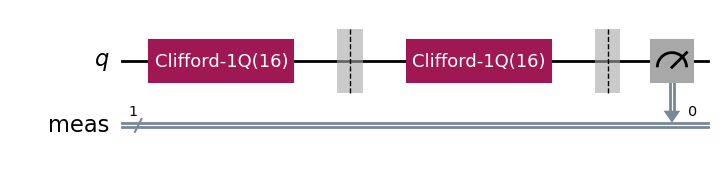

In [53]:
with open('benchmark_data.pkl','rb') as f:
    circuits_list=pickle.load(f)

i = 1 # the circuits are indexed by 0, 1, 2, 3
qc = circuits_list[i][1]
qc.draw('mpl')


In [ ]:
# run experiments and generate the dataset
for backend in backends:
    path = 'random_' + backend + '_counts.pkl'
    paths.append(path)
    x = benchmark(circuits_list, path, backend)
    print("Dataset: length of x = ", len(x))

y = extract_labels(paths,'labels.pkl')
print("Dataset: length of y = ", len(y))

/var/folders/17/k62yccf17rlc56z09zsn12kc4y8rbs/T/ipykernel_14629/1674931637.py:21: DeprecationWarning: get_backend is deprecated since Qiskit v1.1, use backends instead
  backend = provider.get_backend(backend_name)


No existing results found. Starting fresh.
starting circuit: circuit_1
Saved results for circuit: circuit_1
starting circuit: circuit_2
Saved results for circuit: circuit_2
starting circuit: circuit_3
Saved results for circuit: circuit_3
starting circuit: circuit_4
Saved results for circuit: circuit_4
Dataset: length of x =  4
Dataset: length of y =  4


In [ ]:
paths = ['random_Q20_counts.pkl', 'random_Qexa20_counts.pkl']
y = extract_labels(paths, 'labels.pkl')

In [56]:
model_long_V2,path_model_V2 = train_model_long_V2('long_trial_V2', 'benchmark_list_quasm.pkl', "labels.pkl")

Start training for experiment: long_trial_V2
Loading circuits...
Extracting features...
Loading labels...
Loading labels...
Label for circuit_493 not found.
Label for circuit_485 not found.
Label for circuit_453 not found.
Label for circuit_469 not found.
Label for circuit_464 not found.
Label for circuit_490 not found.
Label for circuit_498 not found.
Label for circuit_478 not found.
Label for circuit_456 not found.
Label for circuit_461 not found.
Label for circuit_483 not found.
Label for circuit_497 not found.
Label for circuit_487 not found.
Label for circuit_457 not found.
Label for circuit_488 not found.
Label for circuit_467 not found.
Label for circuit_492 not found.
Label for circuit_476 not found.
Label for circuit_459 not found.
Label for circuit_496 not found.
Label for circuit_489 not found.
Label for circuit_499 not found.
Label for circuit_500 not found.
Label for circuit_462 not found.
Label for circuit_473 not found.
Label for circuit_454 not found.
Label for circuit_

In [ ]:
# This is used to calculate a final accuracy measure by calculating the ratio of correct predictions to all predictions
with open('Test_set','rb') as f:
    data=pickle.load(f)
circuits = []
print(len(data))
for nam,cir in data:
    circuits.append(cir.decompose())
    circuits[-1].name = nam    
#featurdict=create_feature_dict(circuits)
with open("labels.pkl", "rb") as f:
        label_data = pickle.load(f)
correct_count = 0
incorrect_count = 0
non_near_misses=0
near_misses=0
helper_list=[]
for qc in circuits:
    #IMPORTANT if you change FEATURE Methode also change querry method
    result = query_model(model_long_V2, qc)
    
    # Round the result and cast it to an integer
    rounded_result = int(round(result[0])) 
    #rounded_result=int(result)
    if qc.name in label_data:
        label = label_data[qc.name]
        
        if rounded_result == label:
            correct_count += 1
        else:
            incorrect_count += 1
            print(f"Mismatch for circuit {qc.name}: Predicted {rounded_result},TrueValue {result}, Label {label}")
            if abs((label-result[0]))>0.75:
                non_near_misses+=1
                helper_list.append((qc.name,result,label))
            if abs((label-result[0]))<0.6:
                near_misses+=1
    else:
        print(f"Label for circuit {qc.name} not found.")

# Print the final counts
correct_ratio=correct_count/(correct_count+incorrect_count)
print(f"\nTotal correct predictions: {correct_count}")
print(f"Total incorrect predictions: {incorrect_count}")
print(f"Total data points: {correct_count+incorrect_count}")
print(f"Accuracy: {correct_ratio}")
print(f"non_near_misses:{non_near_misses}")
print(f"near_misses:{near_misses}\n")
for (x,y,z) in helper_list:
    print(f"Name: {x}\n Result: {y}\n Label: {z}")


167
Mismatch for circuit circuit_200: Predicted 0,TrueValue [0.], Label 1
Mismatch for circuit circuit_177: Predicted 0,TrueValue [0.075], Label 1
Label for circuit circuit_463 not found.
Label for circuit circuit_475 not found.
Mismatch for circuit circuit_141: Predicted 1,TrueValue [0.9], Label 0
Label for circuit circuit_452 not found.
Label for circuit circuit_477 not found.
Label for circuit circuit_453 not found.
Mismatch for circuit circuit_212: Predicted 0,TrueValue [0.], Label 1
Label for circuit circuit_486 not found.
Label for circuit circuit_451 not found.
Mismatch for circuit circuit_237: Predicted 0,TrueValue [0.], Label 1
Mismatch for circuit circuit_158: Predicted 0,TrueValue [0.], Label 1
Mismatch for circuit circuit_138: Predicted 0,TrueValue [0.15], Label 1
Label for circuit circuit_468 not found.
Mismatch for circuit circuit_181: Predicted 1,TrueValue [0.8], Label 0
Mismatch for circuit circuit_255: Predicted 0,TrueValue [0.], Label 1
Mismatch for circuit circuit_22

In [ ]:


# Load the test set data
with open('Test_set', 'rb') as f:
    data = pickle.load(f)

circuits = []
print(len(data))
for nam, cir in data:
    circuits.append(cir.decompose())
    circuits[-1].name = nam      

# Load the label data
with open("labels.pkl", "rb") as f:
    label_data = pickle.load(f)

# Initialize counters for correct/incorrect predictions for both models
correct_count_1 = 0
incorrect_count_1 = 0
correct_count_2 = 0
incorrect_count_2 = 0

non_near_misses_1 = 0
near_misses_1 = 0
non_near_misses_2 = 0
near_misses_2 = 0

helper_list_1 = []
helper_list_2 = []

# Function to evaluate a model
def evaluate_model(model, circuits, label_data, model_number):
    """!
    @brief Evaluates a trained model on a given set of quantum circuits and compares the predictions with the provided label data.

    This function queries a model with quantum circuits, and compares the model's predictions with the true labels 
    provided in the label_data dictionary. It calculates performance metrics such as accuracy, non-near misses, and near misses.

    @param model The model to be querried.
    @param circuits A list of QuantumCircuit objects to be evaluated by the model.
    @param label_data A dictionary containing the true labels for each quantum circuit, with circuit names as keys.
    @param model_number An integer representing the model number (used for logging purposes).

    @return A tuple containing the following metrics:
        - correct_count: The number of correct predictions made by the model.
        - incorrect_count: The number of incorrect predictions made by the model.
        - non_near_misses: The number of predictions where the model's output differs from the true label by more than 0.75.
        - near_misses: The number of predictions where the model's output differs from the true label by less than 0.6.
        - helper_list: A list of tuples containing circuit names, model predictions, and true labels for cases where the 
          model's prediction was a near miss or non-near miss.
    """
    correct_count = 0
    incorrect_count = 0
    non_near_misses = 0
    near_misses = 0
    helper_list = []
    
    for qc in circuits:
        result = query_model(model, qc)
        
        # Round the result and cast it to an integer
        rounded_result = int(round(result[0])) 
        
        if qc.name in label_data:
            label = label_data[qc.name]
            
            if rounded_result == label:
                correct_count += 1
            else:
                incorrect_count += 1
                print(f"Mismatch for circuit {qc.name} (Model {model_number}): Predicted {rounded_result}, TrueValue {result}, Label {label}")
                if abs((label - result[0])) > 0.75:
                    non_near_misses += 1
                    helper_list.append((qc.name, result, label))
                if abs((label - result[0])) < 0.6:
                    near_misses += 1
        else:
            print(f"Label for circuit {qc.name} not found.")

    return correct_count, incorrect_count, non_near_misses, near_misses, helper_list

# Evaluate both models
correct_count_1, incorrect_count_1, non_near_misses_1, near_misses_1, helper_list_1 = evaluate_model(model_long, circuits, label_data, 1)
correct_count_2, incorrect_count_2, non_near_misses_2, near_misses_2, helper_list_2 = evaluate_model(model_long_V2, circuits, label_data, 2)

# Calculate and print the performance metrics for Model 1
correct_ratio_1 = correct_count_1 / (correct_count_1 + incorrect_count_1)
print(f"\nModel 1 Results:")
print(f"Total correct predictions: {correct_count_1}")
print(f"Total incorrect predictions: {incorrect_count_1}")
print(f"Total data points: {correct_count_1 + incorrect_count_1}")
print(f"Accuracy: {correct_ratio_1}")
print(f"non_near_misses: {non_near_misses_1}")
print(f"near_misses: {near_misses_1}\n")

for (x, y, z) in helper_list_1:
    print(f"Model 1 - Name: {x}\n Result: {y}\n Label: {z}")

# Calculate and print the performance metrics for Model 2
correct_ratio_2 = correct_count_2 / (correct_count_2 + incorrect_count_2)
print(f"\nModel 2 Results:")
print(f"Total correct predictions: {correct_count_2}")
print(f"Total incorrect predictions: {incorrect_count_2}")
print(f"Total data points: {correct_count_2 + incorrect_count_2}")
print(f"Accuracy: {correct_ratio_2}")
print(f"non_near_misses: {non_near_misses_2}")
print(f"near_misses: {near_misses_2}\n")

for (x, y, z) in helper_list_2:
    print(f"Model 2 - Name: {x}\n Result: {y}\n Label: {z}")

# Compare the models' performances
if correct_ratio_1 > correct_ratio_2:
    print("\nModel 1 performed better than Model 2.")
elif correct_ratio_1 < correct_ratio_2:
    print("\nModel 2 performed better than Model 1.")
else:
    print("\nBoth models performed equally well.")


In [ ]:
def query_model_from_onnx(onnx_model, qc:QuantumCircuit)->List[np.ndarray]:
    """! 
    @brief querries the model with a quantum circuit,
      by calculating the feature vector as an dictionary and submitting it to the modle 
    @param onnx_model is the loaded onnx_model
    @param a QuantumCircuit that is submitted 
    """
    input_features = create_feature_dict_V2(qc)
    input_features = np.array(list(input_features.values()), dtype=np.float32).reshape(1, -1)  # Reshaping to (1, n_features)
    input_name = onnx_model.get_inputs()[0].name
    
    output = onnx_model.run(None, {input_name: input_features})
    
    return output
def evaluate_model_onnx(onnx_model_path, circuits, label_data, model_number)->Tuple[int,int,int,int,List]:
    """!
    @brief Evaluates an ONNX model on a given set of quantum circuits and compares the predictions with the provided label data.

    This function loads an ONNX model, queries it with quantum circuits, and compares the model's predictions with the true labels 
    provided in the label_data dictionary. It calculates performance metrics such as accuracy, non-near misses, and near misses.

    @param onnx_model_path The file path to the ONNX model to be loaded.
    @param circuits A list of QuantumCircuit objects to be evaluated by the model.
    @param label_data A dictionary containing the true labels for each quantum circuit, with circuit names as keys.
    @param model_number An integer representing the model number (used for logging purposes).

    @return A tuple containing the following metrics:
        - correct_count: The number of correct predictions made by the model.
        - incorrect_count: The number of incorrect predictions made by the model.
        - non_near_misses: The number of predictions where the model's output differs from the true label by more than 0.75.
        - near_misses: The number of predictions where the model's output differs from the true label by less than 0.6.
        - helper_list: A list of tuples containing circuit names, model predictions, and true labels for cases where the 
          model's prediction was a near miss or non-near miss.
    """

    # Load the ONNX model using onnxruntime
    onnx_model = ort.InferenceSession(onnx_model_path)
    
    correct_count = 0
    incorrect_count = 0
    non_near_misses = 0
    near_misses = 0
    helper_list = []
    
    for qc in circuits:
        # Query the model for predictions
        result = query_model_from_onnx(onnx_model, qc)
        # Round the result and cast it to an integer
        rounded_result = int(round(result[0][0][0])) 

        
        if qc.name in label_data:
            label = label_data[qc.name]
            
            if rounded_result == label:
                correct_count += 1
            else:
                incorrect_count += 1
                print(f"Mismatch for circuit {qc.name} (Model {model_number}): Predicted {rounded_result}, TrueValue {result}, Label {label}")
                if abs((label - result[0])) > 0.75:
                    non_near_misses += 1
                    helper_list.append((qc.name, result, label))
                if abs((label - result[0])) < 0.6:
                    near_misses += 1
        else:
            print(f"Label for circuit {qc.name} not found.")

    return correct_count, incorrect_count, non_near_misses, near_misses, helper_list
# Load the test set data
with open('../Test_set', 'rb') as f:
    data = pickle.load(f)

circuits = []
print(len(data))
for nam, cir in data:
    circuits.append(cir.decompose())
    circuits[-1].name = nam      

# Load the label data
with open("../labels.pkl", "rb") as f:
    label_data = pickle.load(f)

# Initialize counters for correct/incorrect predictions for both models
correct_count_1 = 0
incorrect_count_1 = 0

non_near_misses_1 = 0
near_misses_1 = 0

helper_list_1 = []
path_model_V2='../long_trial_V2.onnx'
correct_count_1, incorrect_count_1, non_near_misses_1, near_misses_1, helper_list_1 = evaluate_model_onnx(path_model_V2, circuits, label_data, 1)



# Calculate and print the performance metrics for Model 1
correct_ratio_1 = correct_count_1 / (correct_count_1 + incorrect_count_1)
print(f"\nModel 1 Results:")
print(f"Total correct predictions: {correct_count_1}")
print(f"Total incorrect predictions: {incorrect_count_1}")
print(f"Total data points: {correct_count_1 + incorrect_count_1}")
print(f"Accuracy: {correct_ratio_1}")
print(f"non_near_misses: {non_near_misses_1}")
print(f"near_misses: {near_misses_1}\n")

for (x, y, z) in helper_list_1:
    print(f"Model 1 - Name: {x}\n Result: {y}\n Label: {z}")


167
here is a result
[array([[0.]], dtype=float32)]
here is a result
[array([[0.]], dtype=float32)]
here is a result
[array([[0.]], dtype=float32)]
here is a result
[array([[2.0000002]], dtype=float32)]
here is a result
[array([[0.]], dtype=float32)]
here is a result
[array([[2.0000002]], dtype=float32)]
here is a result
[array([[0.]], dtype=float32)]
here is a result
[array([[0.]], dtype=float32)]
Mismatch for circuit circuit_200 (Model 1): Predicted 0, TrueValue [array([[0.]], dtype=float32)], Label 1
here is a result
[array([[0.]], dtype=float32)]
here is a result
[array([[0.]], dtype=float32)]
here is a result
[array([[0.]], dtype=float32)]
here is a result
[array([[0.075]], dtype=float32)]
here is a result
[array([[0.]], dtype=float32)]
here is a result
[array([[0.]], dtype=float32)]
here is a result
[array([[0.]], dtype=float32)]
here is a result
[array([[2.0000002]], dtype=float32)]
here is a result
[array([[0.]], dtype=float32)]
here is a result
[array([[2.0000002]], dtype=floa

In [25]:
import networkx as nx
import re
def calc_supermarq_plus_from_QKE_Pass (file_path):
    """!
    @brief Calculates the Supermarq features and additional features for a txt file resulting from an Analysis Pass of a quantum circuit in Qake dialect.

    This function computes the Supermarq features as well as three additional features designed to address 
    certain limitations of the original Supermarq features. These features provide insights into the quantum 
    circuit's structure and behavior. The implementation is adapted from:
    https://github.com/Infleqtion/client-superstaq/blob/91d947f8cc1d99f90dca58df5248d9016e4a5345/supermarq-benchmarks/supermarq/converters.py.

    @param file_path This string is the path to the txt file containing the Passes results.
    @return A tuple containing the Supermarq features and additional features for the quantum circuit. The 
            features are as follows:
            - Program communication
            - Critical depth
            - Entanglement ratio
            - Parallelism
            - Liveness
            - Directed program communication
            - Average number of 1-qubit gates
            - Average number of 2-qubit gates
            - Depth (number of layers)
            - Number of qubits in the circuit
    """
    qubits_set=set()
    num_2_qbit_operations=0
    num_1_qbit_operations=0
    num_2_qbit_operations_on_dag_path=0
    di_interact_graph=nx.DiGraph()
    di_circuit_graph=nx.DiGraph()
    latest_record={}
    two_qubit_gates={}
    gates={}
    #-------------


    with open(file_path, "r") as f:
        lines = f.readlines()

    i = 0
    while i < len(lines):
        line = lines[i].strip()
        
        # Skip the header line
        if line.startswith("Captured output"):
            i += 1
            continue

        # Process the "Quantum Operation:" block
        if line.startswith("Quantum Operation:"):
            # Extract the operation name (everything after the colon)
            op = line.split(":", 1)[1].strip()
            op=op.strip('quake.')
            # Next line: "Target Qubits:"
            i += 1
            if i >= len(lines):
                break
            target_line = lines[i].strip()
            if target_line.startswith("Target Qubits:"):
                # Extract all numbers as integers
                targets = [int(num) for num in re.findall(r'\d+', target_line)]
                # Make sure there is at least one target value
                if not targets:
                    raise ValueError("Target list must have at least one value.")
            else:
                raise ValueError("Expected 'Target Qubits:' line but got: " + target_line)
            
            # Next line: "Control Qubits:"
            i += 1
            if i >= len(lines):
                break
            control_line = lines[i].strip()
            if control_line.startswith("Control Qubits:"):
                # Extract all numbers as integers (this list can be empty)
                controls = [int(num) for num in re.findall(r'\d+', control_line)]
            else:
                raise ValueError("Expected 'Control Qubits:' line but got: " + control_line)
            if len(controls)!=0:
                op='c'+op
            # Save the tuple (operation, target list, control list)
            for qubit in targets + controls:
                if qubit not in qubits_set:
                    latest_record[qubit]="init"+str(qubit)
                    qubits_set.add(qubit)
            #(op, targets, controls)

            if (len(targets)==1 and not controls):
                gate_name=op+"_"+str(num_1_qbit_operations)
                di_circuit_graph.add_edge(latest_record[targets[0]],gate_name)
                num_1_qbit_operations+=1
                latest_record[targets[0]]=gate_name
                gates[gate_name]=targets
            elif len(targets)==1 and len(controls)==1:
                gate_name=op+"_"+str(num_2_qbit_operations)
                di_circuit_graph.add_edge(latest_record[controls[0]],gate_name)
                di_circuit_graph.add_edge(latest_record[targets[0]],gate_name)
                latest_record[controls[0]]=gate_name
                latest_record[targets[0]]=gate_name
                num_2_qbit_operations+=1
                two_qubit_gates[gate_name]=1
                di_interact_graph.add_edge(controls[0],targets[0])
                gates[gate_name]=controls+targets      
            else:
                print("ERROR: Gate with more than 2 qubits")
        i+=1
    #-------------
    num_qubits=len(qubits_set)         
    for qubit in range(0,num_qubits):
        di_circuit_graph.add_edge(latest_record[qubit],"final"+str(qubit))
        di_interact_graph.add_node(qubit)
    dag=nx.dag_longest_path(di_circuit_graph)
    for helper in dag:
        if helper in two_qubit_gates:
            num_2_qbit_operations_on_dag_path+=1
    #dag_len=nx.dag_longest_path_length(di_circuit_graph)
    undi_interact_graph=di_interact_graph.to_undirected()
    if num_2_qbit_operations>0:
        degree_sum = sum(undi_interact_graph.degree(n) for n in undi_interact_graph.nodes)
        degree_sum2 = sum(di_interact_graph.degree(n) for n in di_interact_graph.nodes)
    
    else:
        degree_sum=0.0
        degree_sum2=0.0
    max_degree = num_qubits * (num_qubits - 1)  # Degree of a complete graph
    
    program_communication = degree_sum / max_degree if max_degree > 0 else 0
    directed_program_communication = degree_sum2 / (2 * num_qubits * (num_qubits - 1)) if num_qubits > 1 else 0
    
    #TODO: Verfiy layers correct
    topological_order = list(nx.topological_sort(di_circuit_graph))
    
    # Now create layers based on the topological sort
    layers = []
    current_layer = []
    nodes_in_current_layer = set()

    for node in topological_order:
        if "init" in node or "final" in node:
            continue
        
        # Check if the node has dependencies in the current layer
        predecessors = list(di_circuit_graph.predecessors(node))
        if not any(pred in nodes_in_current_layer for pred in predecessors):
            # Add the node to the current layer
            current_layer.append(node)
            nodes_in_current_layer.add(node)
        else:
            # If dependencies exist in the current layer, move to the next layer
            layers.append(current_layer)
            current_layer = [node]
            nodes_in_current_layer = {node}

    # Add the last layer if it exists
    if current_layer:
        layers.append(current_layer)
    
    depth=len(layers)
    num_gates=num_1_qbit_operations+num_2_qbit_operations
    # Average number of 1q gates = num of 1-qubit gates in the circuit / (num qubits * depth)
    single_qubit_gates = (
        (num_1_qbit_operations) / (num_qubits * depth)
        if depth > 0 and num_qubits > 0
        else 0
    )
    #Average number of 2q gates = num of 2-qubit gates in the circuit / (num qubits * depth)
    multi_qubit_gates = (
        (num_2_qbit_operations) / ((num_qubits // 2) * depth) if depth > 0 and num_qubits > 1 else 0
    )
    if num_2_qbit_operations>0:
        entanglement_ratio = num_2_qbit_operations / num_gates if num_gates > 0 else 0
    else:
        entanglement_ratio=0.0
    # Critical depth = # of 2-qubit gates along the critical path / total # of 2-qubit gates.
    if(num_qubits)>1:
        n_ed = num_2_qbit_operations_on_dag_path
        n_e = num_2_qbit_operations
        critical_depth = n_ed / n_e if n_e != 0 else 0
    else:
        critical_depth=1.0
    
    parallelism = ((num_gates / depth) - 1) / (num_qubits - 1) if num_qubits > 1 and depth > 0 else 0
    liveness=0.5
    activity_matrix = np.zeros((num_qubits, depth))
    for i, layer in enumerate(layers):
        for op in layer:
            qubits=gates[op]
            for qubit in qubits:
                activity_matrix[qubit, i] = 1
    max_activity = num_qubits * depth
    liveness = np.sum(activity_matrix) / max_activity if max_activity > 0 else 0

    assert 0 <= program_communication <= 1
    assert 0 <= critical_depth <= 1
    assert 0 <= entanglement_ratio <= 1
    assert 0 <= parallelism <= 1
    assert 0 <= liveness <= 1

    assert 0 <= directed_program_communication <= 1
    assert 0 <= single_qubit_gates <= 1
    assert 0 <= multi_qubit_gates <= 1

    return (
        float(program_communication),
        float(critical_depth),
        float(entanglement_ratio),
        float(parallelism),
        float(liveness),
        float(directed_program_communication),
        float(single_qubit_gates),
        float(multi_qubit_gates),
        float(num_qubits),
        float(depth)
    )
def create_feature_dict_from_QKE_pass(file_path:str) -> dict[str, float]:
    """!
    @brief Creates and returns a feature dictionary for a file path to a txt file on the results from an analysis pass of a qke file in qke dialect.

    This function analyzes a quantum circuit and creates a feature dictionary containing various 
    characteristics of the circuit, such as depth, number of qubits, and Supermarq features (e.g., 
    program communication, critical depth, entanglement ratio). It uses the `calc_supermarq_plus_features` 
    function to compute additional features specific to the quantum circuit.

    @param qc The quantum circuit to be analyzed.
    @return A dictionary containing the features of the quantum circuit. The features include:
            - analysis of the occuring gates check check_gates_in_circuits for which gates
            - "depth" (float): The depth of the quantum circuit.
            - "num_qubits" (float): The number of qubits in the quantum circuit.
            - "program_communication" (float): The program communication feature of the circuit.
            - "critical_depth" (float): The critical depth of the circuit.
            - "entanglement_ratio" (float): The entanglement ratio of the circuit.
            - "parallelism" (float): The parallelism feature of the circuit.
            - "liveness" (float): The liveness feature of the circuit.
            - "directed_program_communication" (float): The directed program communication feature.
            - "single_qubit_gates" (float): The number of single-qubit gates used.
            - "multi_qubit_gates" (float): The number of multi-qubit gates used.
    """
    
    feature_dict: dict[str, float] = {}
    
   
   
    supermarq_features = calc_supermarq_plus_from_QKE_Pass(file_path)
    feature_dict["depth"] = supermarq_features[9]
    feature_dict["num_qubits"] = supermarq_features[8]
    feature_dict["program_communication"] = supermarq_features[0]
    feature_dict["critical_depth"] = supermarq_features[1]
    feature_dict["entanglement_ratio"] = supermarq_features[2]
    feature_dict["parallelism"] = supermarq_features[3]
    feature_dict["liveness"] = supermarq_features[4]

    feature_dict["directed_program_communication"] = supermarq_features[5]
    feature_dict["single_qubit_gates"] = supermarq_features[6]
    feature_dict["multi_qubit_gates"] = supermarq_features[7]

    return feature_dict

In [26]:
print(create_feature_dict_from_QKE_pass('../test_file_pass_result.txt'))

{'depth': 10.0, 'num_qubits': 10.0, 'program_communication': 0.2, 'critical_depth': 1.0, 'entanglement_ratio': 0.9, 'parallelism': 0.0, 'liveness': 0.19, 'directed_program_communication': 0.1, 'single_qubit_gates': 0.01, 'multi_qubit_gates': 0.18}


In [22]:

from qiskit import QuantumCircuit

qc = QuantumCircuit(10)

qc.h(0)
qc.cx(0, 1)
qc.cx(1, 2)
qc.cx(2, 3)
qc.cx(3, 4)
qc.cx(4, 5)
qc.cx(5, 6)
qc.cx(6, 7)
qc.cx(7, 8)
qc.cx(8, 9)

qc.draw('mpl')

print(create_feature_dict(qc))

{'depth': 10.0, 'num_qubits': 10.0, 'program_communication': 0.2, 'critical_depth': 1.0, 'entanglement_ratio': 0.9, 'parallelism': 0.0, 'liveness': 0.19, 'directed_program_communication': 0.1, 'single_qubit_gates': 0.01, 'multi_qubit_gates': 0.18}


In [ ]:
#execution Script:
#-------------
num_qubits=np.arange(1,13) #test 12 qubits,
lengths=np.arange(1,5) # number of folds 1 to 4
samples=60 #70 samples over each qubit number and folds
#backends=['QExa20','AQT20','QLM']
backends=['QExa20']
path_string='_qubits_1-'+str(num_qubits[len(num_qubits)-1])+'_folds_1-'+str(lengths[len(lengths)-1])+'_samples_'+str(samples)
data_paths=[]
label_path='labels_'+path_string+'.pkl'
model_name='Model_long_V2'
#--------------
bench_path='Randombenchmark'+path_string+'.pkl'
if not(Path(bench_path).exists()):
    print('generate Random_Benchmark data')
    Circuits=generate_random_Benchmark_circuits(num_samples=samples,lengths=lengths,qubits=num_qubits,path=bench_path)
else:
    print('loading exsisting data')
    with open(bench_path,'rb')as f:
        Circuits=pickle.load(f)
print('starting data collection')
for x in backends:
    print('Starting with device '+x)
    path='Randombenchmark_'+path_string+'_'+x+'.pkl'
    data_paths.append(path)
    data=benchmark(backend_name=x,shots=200,quantum_circuits=Circuits,path=path)
print('Starting label extraction')
label_data=extract_labels(data_sets_paths=data_paths,path=label_path)
print('Starting Model-training')
model_long,model_path = train_model_long_V2(experiment_name=model_name,circuits_path=bench_path , label_path=label_path)
print('Model '+model_name+' trained. Path = '+model_path)


loading exsisting data
starting data collection
Starting with device QExa20


/var/folders/76/gt71n20x1sl9m4rfjr_h8p78wsz8w6/T/ipykernel_83353/1440629098.py:21: DeprecationWarning: get_backend is deprecated since Qiskit v1.1, use backends instead
  backend = provider.get_backend(backend_name)


Loaded existing results from Randombenchmark__qubits_1-12_folds_1-4_samples_60_QExa20.pkl.
starting circuit: circuit_1421
Saved results for circuit: circuit_1421
starting circuit: circuit_1500
Saved results for circuit: circuit_1500
starting circuit: circuit_1513
Saved results for circuit: circuit_1513
starting circuit: circuit_1544
Saved results for circuit: circuit_1544
starting circuit: circuit_1545
Saved results for circuit: circuit_1545
starting circuit: circuit_1546
Saved results for circuit: circuit_1546
starting circuit: circuit_1547
Saved results for circuit: circuit_1547
starting circuit: circuit_1548
Saved results for circuit: circuit_1548
starting circuit: circuit_1549
Saved results for circuit: circuit_1549
starting circuit: circuit_1550
Saved results for circuit: circuit_1550
starting circuit: circuit_1551
Saved results for circuit: circuit_1551
starting circuit: circuit_1552
Saved results for circuit: circuit_1552
starting circuit: circuit_1553
Saved results for circuit:

In [ ]:
#circuits 1-355 115min
#circuits 355-800 65 min
#circuits 800-1322 111min